In [1]:
%load_ext autoreload
%autoreload 2

In [14]:
from ariel_pred.dataset import DataLoaderAndCalibrator
from ariel_pred.preprocessing import SGSmoothing
from ariel_pred.plots import plot_white_curve
import matplotlib.pyplot as plt
from pathlib import Path

In [ ]:
data_loader = DataLoaderAndCalibrator(
    data_path=Path("../data/raw_subset"),
    output_path=Path("../data/calibrated/subset_cut_channels"),
    force_recalibration=False,
    cut_airs_channels=True,
    binning=4,
    n_jobs=4
)

In [ ]:
train_data, train_labels = data_loader.load_all_train_data()

Calibrating and saving train data...


QUEUEING TASKS | :   0%|          | 0/9 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/9 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/9 [00:00<?, ?it/s]

QUEUEING TASKS | :   0%|          | 0/9 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/9 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/9 [00:00<?, ?it/s]

In [7]:
train_data.shape, train_labels.shape

((9, 1406, 283), (9, 283))

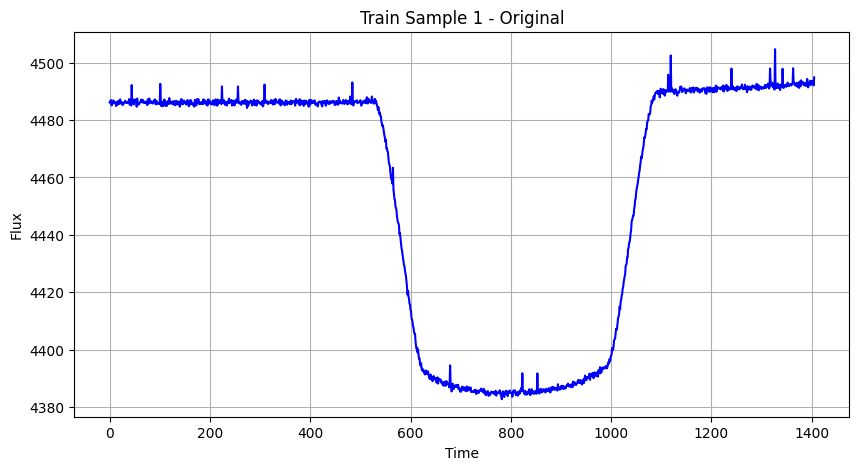

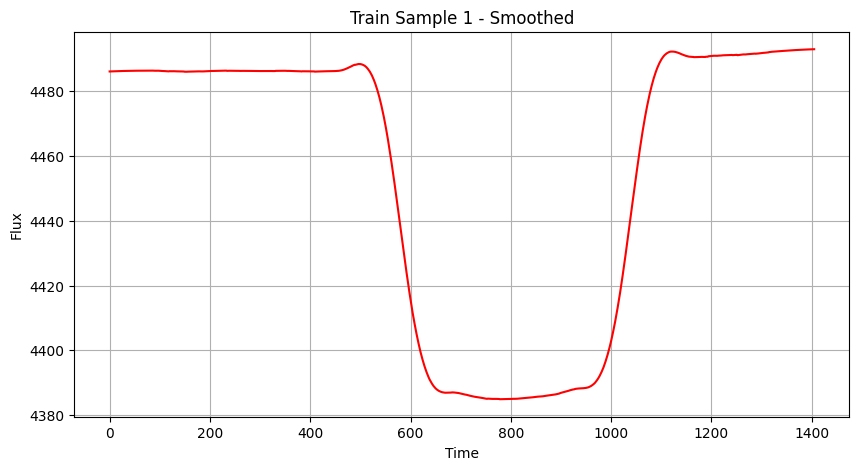

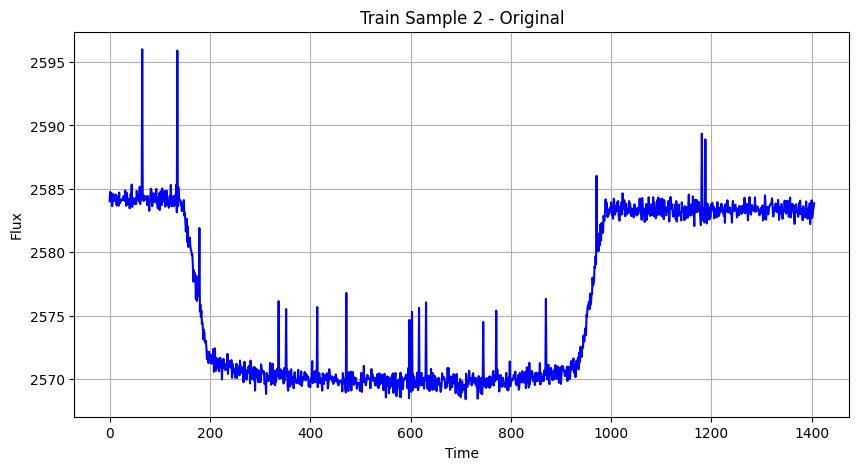

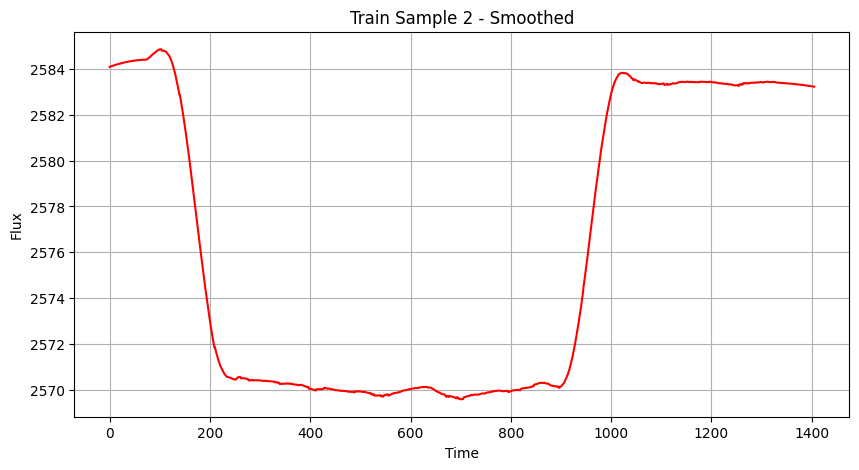

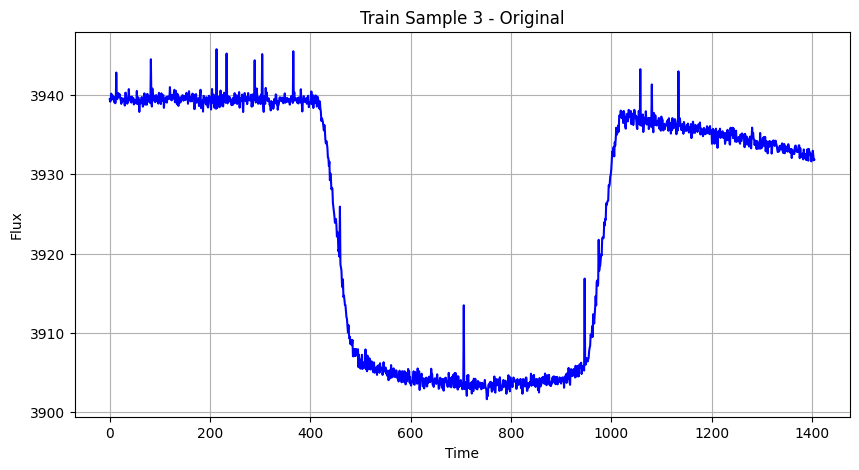

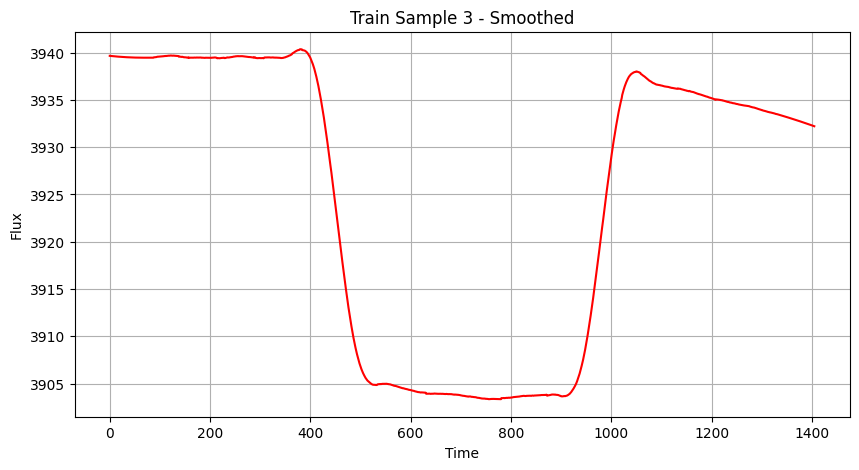

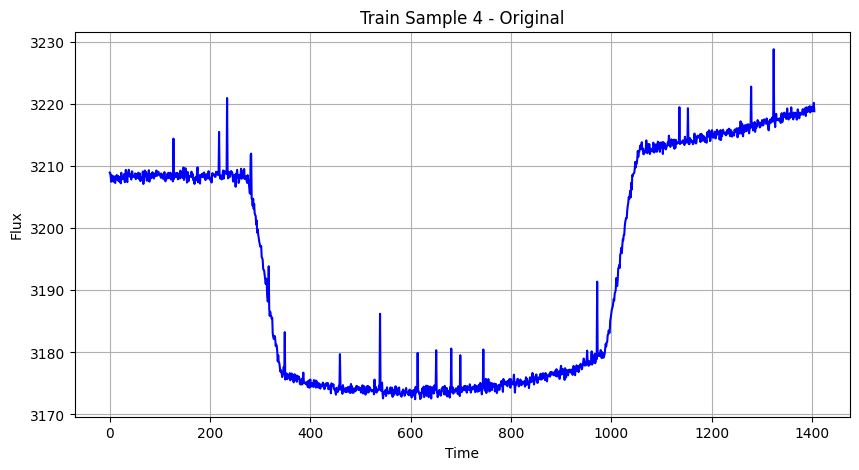

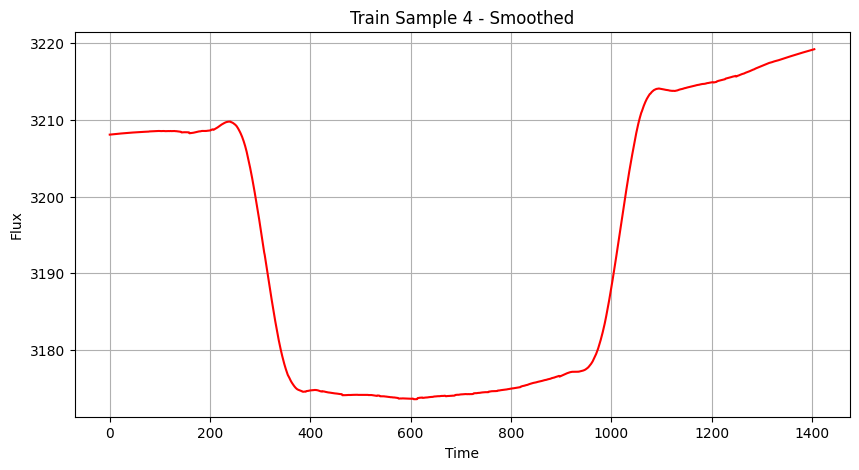

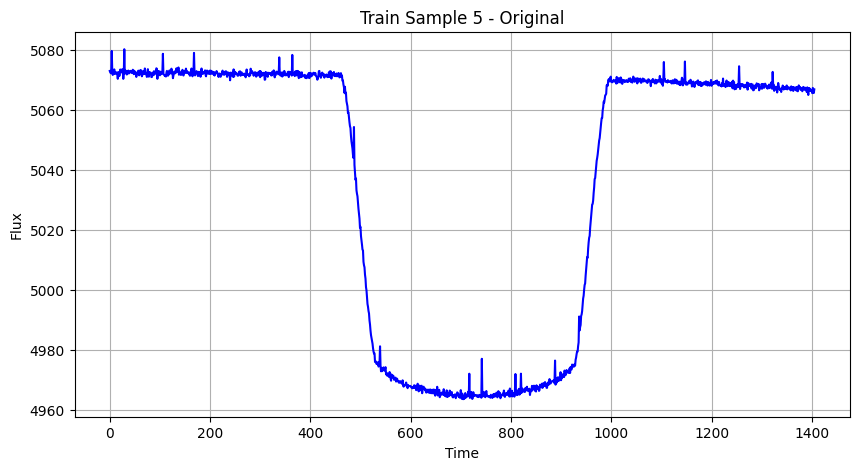

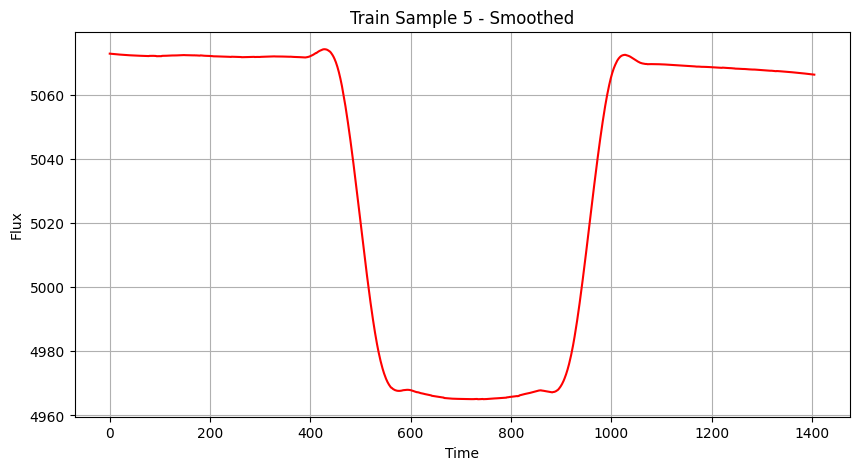

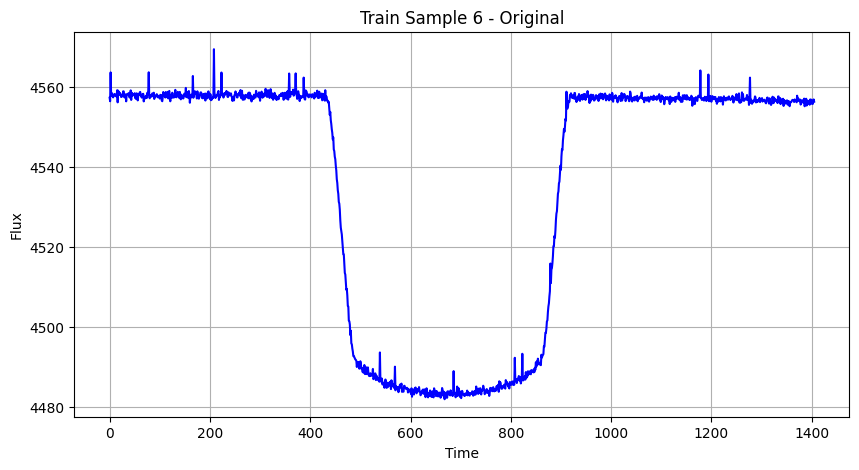

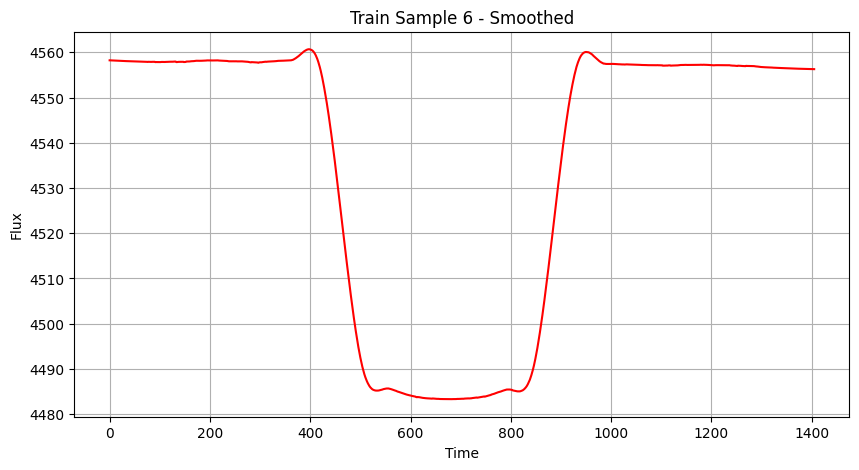

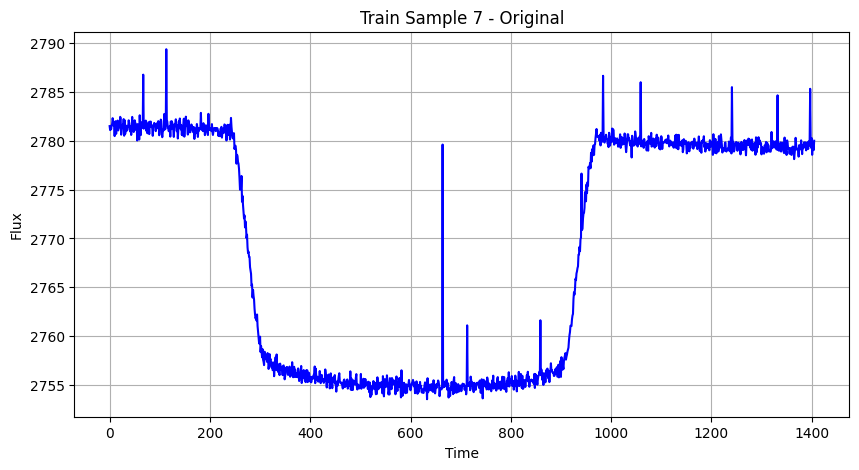

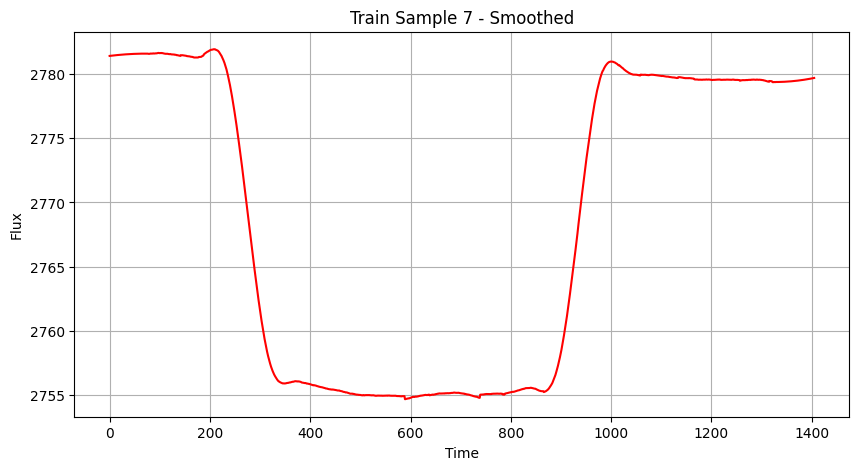

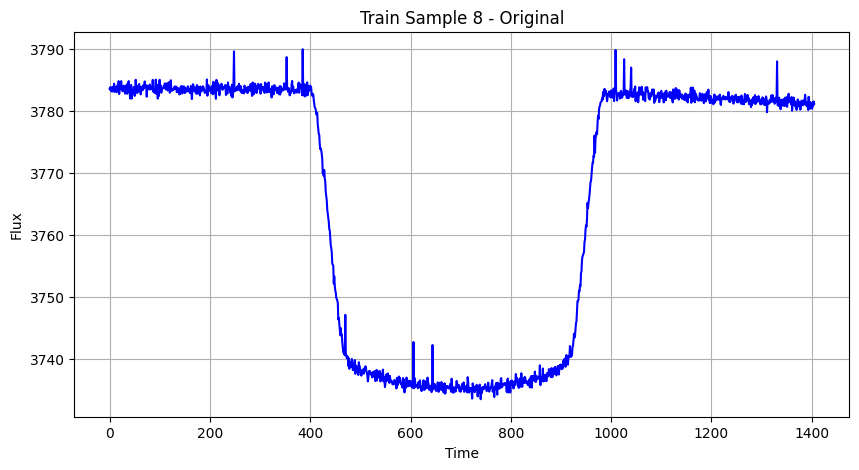

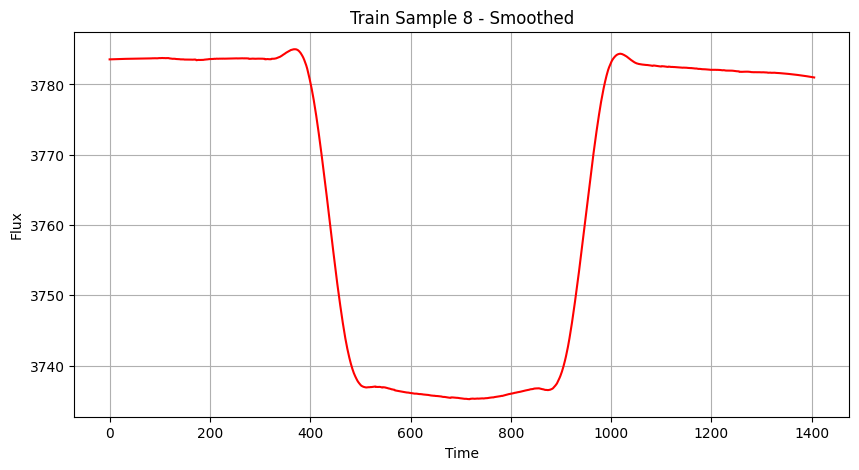

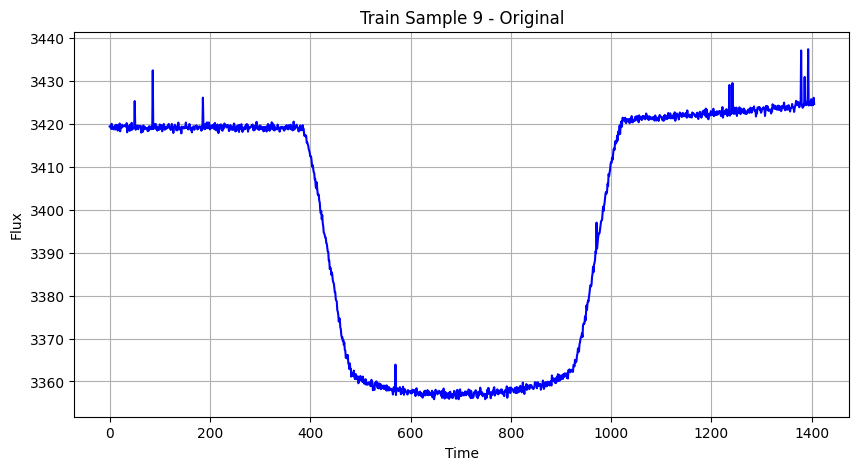

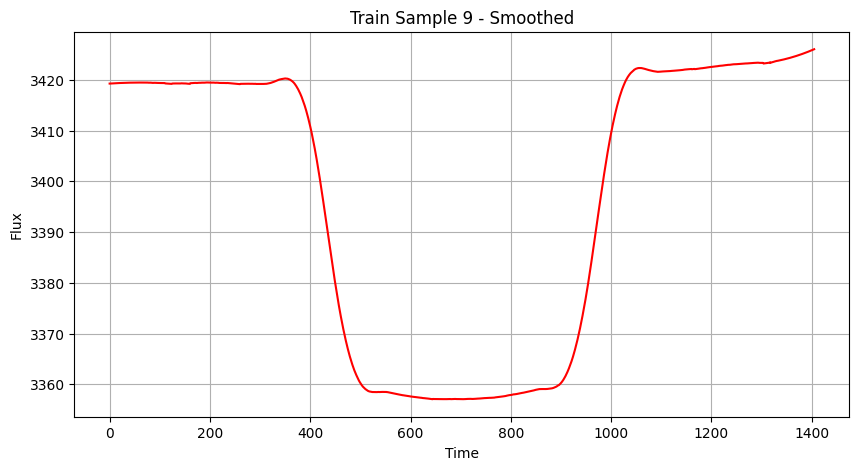

In [22]:
smoother = SGSmoothing(window_size=150, poly_order=2)
for i in range(min(10, train_data.shape[0])):
    # Plot original and smoothed white curve for first 10 samples
    plot_white_curve(train_data[i], title=f"Train Sample {i+1} - Original", color="blue")
    plot_white_curve(smoother.smooth(train_data[i].mean(axis=1)), title=f"Train Sample {i+1} - Smoothed", color="red")
    plt.show()